In [28]:
import json
import pandas as pd


In [66]:
df = pd.DataFrame().from_records([json.loads(i) for i in open("domain_res.jsonl", 'r').readlines()])
df["domain"] = df["domain"].str.lower().str.capitalize()
allowed_domains = [
    "Statistics and probability", 
    "Math",
    "Computer science",
    "Natural language processing",
    "Data science",
    "Computer vision"
]

# Update values in the 'domain' column
df["domain"] = df["domain"].apply(lambda x: x if x in allowed_domains else "Other")
df

,term,domain
0,AI,Other
1,API,Computer science
2,AQA,Other
3,ARENA,Other
4,Additionally,Other
...,...,...
4985,zero-shot prompting,Natural language processing
4986,zero-shot reasoning,Other
4987,zero-shot setting,Other
4988,zero-shot transfer,Other


In [67]:
df['domain'].value_counts()

domain
Other                          1729
Statistics and probability      664
Math                            611
Computer science                586
Natural language processing     574
Data science                    498
Computer vision                 328
Name: count, dtype: int64

bar plot


/tmp/ipykernel_2609820/2852641348.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', len(domains))  # Use a scientific colormap like 'viridis'


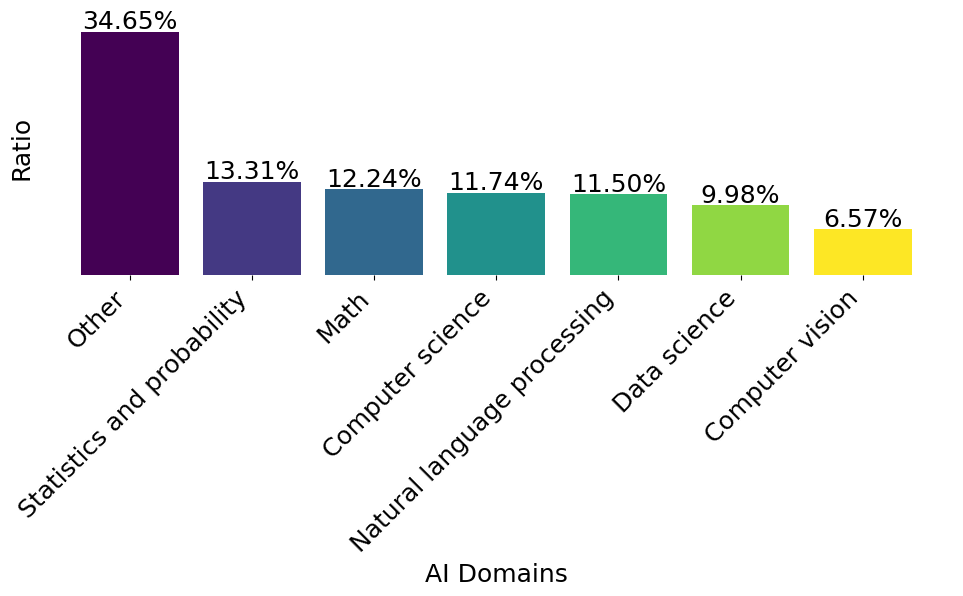

In [68]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Data
domains = [
    "Other",
    "Statistics and probability",
    "Math",
    "Computer science",
    "Natural language processing",
    "Data science",
    "Computer vision"
]

values = [1729, 664, 611, 586, 574, 498, 328]
total = 4990
ratios = [v / total for v in values]

# Define a colormap
cmap = cm.get_cmap('viridis', len(domains))  # Use a scientific colormap like 'viridis'
colors = [cmap(i) for i in range(len(domains))]

# Plotting
plt.figure(figsize=(10, 6))
bars = plt.bar(domains, ratios, color=colors)

# Remove border lines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# Remove y-ticks
plt.yticks([])

# Adding labels and title
plt.xlabel("AI Domains", fontsize=18)
plt.ylabel("Ratio", fontsize=18)
# plt.title("Distribution of AI Subfields", fontsize=18)
plt.xticks(rotation=45, ha='right', fontsize=18)

# Add ratio values on top of the bars
for bar, ratio in zip(bars, ratios):
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # Center text horizontally
        bar.get_height() + 0.005,  # Slightly above the bar
        f"{ratio:.2%}",  # Format as percentage
        ha='center',
        fontsize=18
    )

# Tight layout for better appearance
plt.tight_layout()
# plt.show()
# Save the plot as a PDF with a tight bounding box
plt.savefig("domain_coverage.pdf", format="pdf", bbox_inches="tight")



embedding model + t-sne dimension reduction

In [69]:
from sklearn.manifold import TSNE
from sentence_transformers import SentenceTransformer
# Load the pre-trained model
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# Generate embeddings for the "term" column
embeddings = model.encode(df["term"].tolist())

In [22]:
df["domain"].value_counts().index[:7]

Index(['Other', 'Statistics and probability', 'Math', 'Computer science',
       'Natural language processing', 'Data science', 'Computer vision'],
      dtype='object', name='domain')

In [26]:
# Perform t-SNE dimensionality reduction
# tsne = TSNE(n_components=2, random_state=42, perplexity=5, n_iter=1000)
tsne = TSNE(n_components=2, perplexity=30, n_iter=3000, random_state=42, learning_rate=200)
embeddings_2d_tsne = tsne.fit_transform(embeddings)


/data/user_data/jiaruil5/miniconda3/envs/mmc/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


/tmp/ipykernel_2600125/939634312.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(unique_domains))


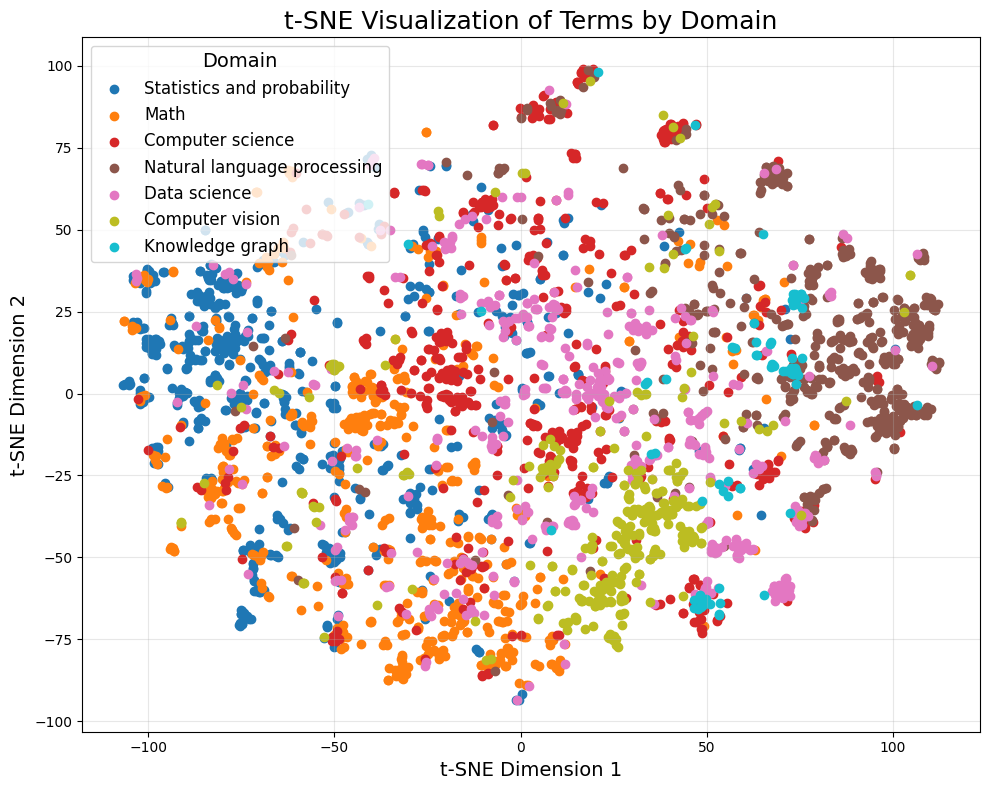

In [30]:

# Plotting
plt.figure(figsize=(10, 8))

unique_domains = ['Statistics and probability', 'Math', 'Computer science',
       'Natural language processing', 'Data science', 'Computer vision', 'Knowledge graph']

colors = plt.cm.get_cmap("tab10", len(unique_domains))

for idx, domain in enumerate(unique_domains):
    domain_mask = df["domain"] == domain
    plt.scatter(
        embeddings_2d_tsne[domain_mask, 0], 
        embeddings_2d_tsne[domain_mask, 1], 
        label=domain, 
        color=colors(idx)
    )

plt.title("t-SNE Visualization of Terms by Domain", fontsize=18)
plt.xlabel("t-SNE Dimension 1", fontsize=14)
plt.ylabel("t-SNE Dimension 2", fontsize=14)
plt.legend(title="Domain", fontsize=12, title_fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

a better version

In [70]:
import umap

# Perform UMAP dimensionality reduction
umap_reducer = umap.UMAP(n_components=2, random_state=42)
embeddings_2d = umap_reducer.fit_transform(embeddings)


/data/user_data/jiaruil5/miniconda3/envs/mmc/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/tmp/ipykernel_2609820/789296654.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(unique_domains))


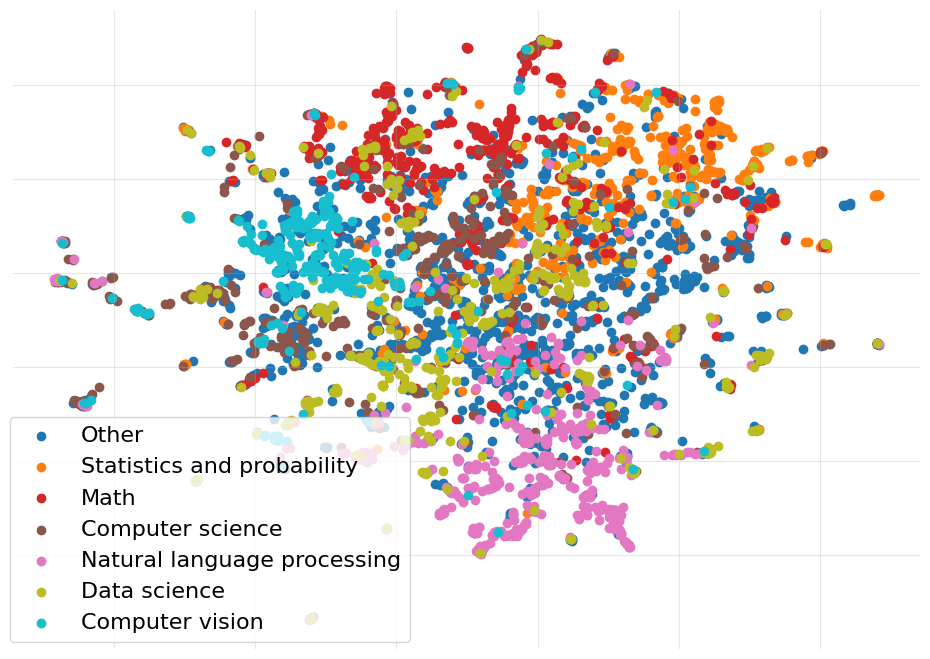

In [71]:
# Plotting remains the same as with t-SNE
plt.figure(figsize=(10, 7))

unique_domains = ['Other', 'Statistics and probability', 'Math', 'Computer science',
       'Natural language processing', 'Data science', 'Computer vision']

colors = plt.cm.get_cmap("tab10", len(unique_domains))

for idx, domain in enumerate(unique_domains):
    domain_mask = df["domain"] == domain
    plt.scatter(
        embeddings_2d[domain_mask, 0], 
        embeddings_2d[domain_mask, 1], 
        label=domain, 
        color=colors(idx)
    )

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# plt.title("UMAP Visualization of Terms by Domain", fontsize=18)
plt.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
# plt.legend(fontsize=16)
plt.legend(fontsize=16, bbox_to_anchor=(0.45, 0.38), ncol=1)

plt.grid(alpha=0.3)
plt.tight_layout()
# plt.show()
plt.savefig("domain_umap.pdf", format="pdf", bbox_inches="tight")

wordcloud

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from wordcloud import WordCloud

# Step 1: Manually create the "AI" mask
# Dimensions for the image
width, height = 1800, int(1800 / 6 * 3.8)

# Create a blank white image
ai_image = Image.new("L", (width, height), "white")
draw = ImageDraw.Draw(ai_image)

# Define the bold "AI" shape
# Manually create thick "A" and "I"


w = width / 6
h = height / 3.8

# draw.rectangle([(0.0 * w, 0.0 * h), (3.8 * w, 6.0 * h)], fill="white")

draw.polygon([(0.4 * w, 3.7 * h), (1.4 * w, 3.7 * h), (2.8 * w, 0.1 * h), (1.8 * w, 0.1 * h)], fill="black")  # Left bar of "A"
draw.polygon([(3.2 * w, 3.7 * h), (4.2 * w, 3.7 * h), (2.8 * w, 0.1 * h), (1.8 * w, 0.1 * h)], fill="black")  # Right bar of "A"
draw.rectangle([(1.3 * w, 2.1 * h), (3.2 * w, 3.1 * h)], fill="black")  # Hole in "A"

draw.rectangle([(4.6 * w, 0.1 * h), (5.6 * w, 3.7 * h)], fill="black")  # "I"

# Save the mask as an image for visualization
ai_image.save("AI_mask.pdf")

# Step 2: Convert the image to a NumPy array for the WordCloud mask
mask_image = np.array(ai_image)

[nltk_data] Downloading package punkt to /home/jiaruil5/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt to /home/jiaruil5/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


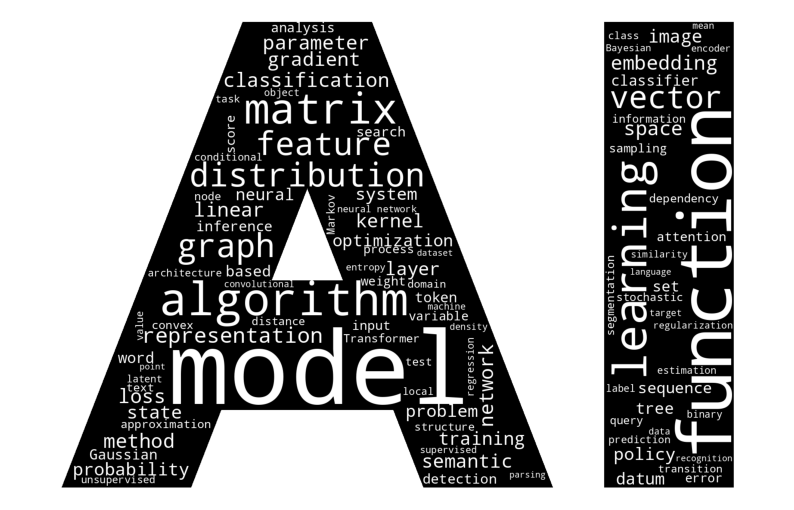

In [64]:
import nltk
nltk.download('punkt')  # Download the punkt tokenizer
import pandas as pd
from wordcloud import WordCloud
from nltk.tokenize import word_tokenize
import matplotlib.pyplot as plt
import nltk

# Download the punkt tokenizer if not already downloaded
nltk.download('punkt')

# Tokenize terms into individual words
all_words = []
for term in df['term']:
    all_words.extend(word_tokenize(term))

# Combine all words into a single string for WordCloud
text = " ".join(all_words)

def black_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    return "white"

# Generate the WordCloud
# wordcloud = WordCloud(width=2400, height=1800, background_color="white", max_words=200).generate(text)
wordcloud = WordCloud(
    width=1800,
    height=1800,
    background_color="black",
    mask=mask_image,
    contour_width=1,
    contour_color="black",
    max_words=100,
    color_func=black_color_func  # Set font colors to black
).generate(text)

final_img = Image.new("RGB", (width, height), "white")

# Convert wordcloud to PIL Image
wc_image = Image.fromarray(wordcloud.to_array())

# Create mask for compositing (black areas from original mask)
mask = Image.fromarray(mask_array).convert("L")
mask = Image.eval(mask, lambda x: 255 if x == 0 else 0)
# Paste the wordcloud only where the mask is black
final_img.paste(wc_image, (0, 0), mask)

# Save the final result
plt.figure(figsize=(10, 10))
plt.imshow(final_img)
plt.axis("off")
plt.savefig("wordcloud.pdf", format="pdf", bbox_inches="tight", dpi=1800, facecolor="white")